# Module 10 Lab — Unsupervised Learning
## Applied to FIELDPROOF™ — Sensor-Verified Human Task Execution

**Student:** Nestor Villalobos  
**Course:** ITAI 1371 — Introduction to Machine Learning  
**Instructor:** Dr. Sina Nazifi  
**Semester:** Spring 2026  
**Institution:** Houston City College

---

## 🎯 Lab Objective

Learn and apply two foundational **unsupervised learning** techniques:
1. **K-Means Clustering** — to find natural groupings in data without any labels
2. **Principal Component Analysis (PCA)** — to reduce dimensionality while preserving variance

In this lab I apply both methods to the FIELDPROOF simulated operations dataset to see what structure exists in the sensor data *before* any compliance labels are considered.

## 🏗️ Why This Matters for FIELDPROOF

FIELDPROOF collects nine continuous sensor-derived signals per task record (`duration_min`, `motion_intensity`, `posture_correctness`, `zone_presence_score`, `sequence_score`, `fatigue_index`, `anomaly_score`, `compliance_score`, `risk_score`). The supervised labs (08, 09, 11, 12) all used the `verification_status` label as the target. This lab asks a different question:

**What natural structure exists in the sensor data itself, without looking at the labels?**

The operational value of this is real:
- If K-Means discovers natural clusters in the sensor data that correspond to different *kinds* of task execution patterns, FIELDPROOF can use those clusters to flag records for review even when it doesn't have a reliable label yet — useful during the cold-start phase of a new deployment.
- If PCA shows that the nine sensor signals are highly correlated and can be compressed to 2–3 components without losing much information, we can save compute and storage at the edge. If PCA shows the signals are *not* highly correlated, we have evidence that every sensor is pulling its weight and shouldn't be cut.

## Part 1: Supervised vs Unsupervised Learning

Every model I have built in the FIELDPROOF labs so far has been **supervised** — I had both the features (X) and the correct answer (y). The goal was to learn a mapping from X to y.

In **unsupervised** learning I only have the features (X). There is **no target variable**. The goal is to discover structure in the data on its own.

Two major unsupervised techniques, both covered in this lab:

- **Clustering** — automatically grouping similar data points together. K-Means is the classic algorithm.
- **Dimensionality Reduction** — compressing the data by reducing the number of features while preserving information. PCA is the classic algorithm.

## Part 2: K-Means Clustering on FIELDPROOF Sensor Data

K-Means finds a pre-defined number of clusters (`k`) in a dataset by:

1. Randomly placing `k` centroids in the feature space
2. **Assignment step** — assigning each data point to its nearest centroid
3. **Update step** — moving each centroid to the average position of the points assigned to it
4. Repeating until the centroids stop moving

Instead of the lab template's synthetic blobs, I use the nine continuous sensor features from FIELDPROOF. The question: **do field-task records naturally group into operationally meaningful clusters?**

Feature matrix shape: (500, 9)   (500 records, 9 sensor signals)


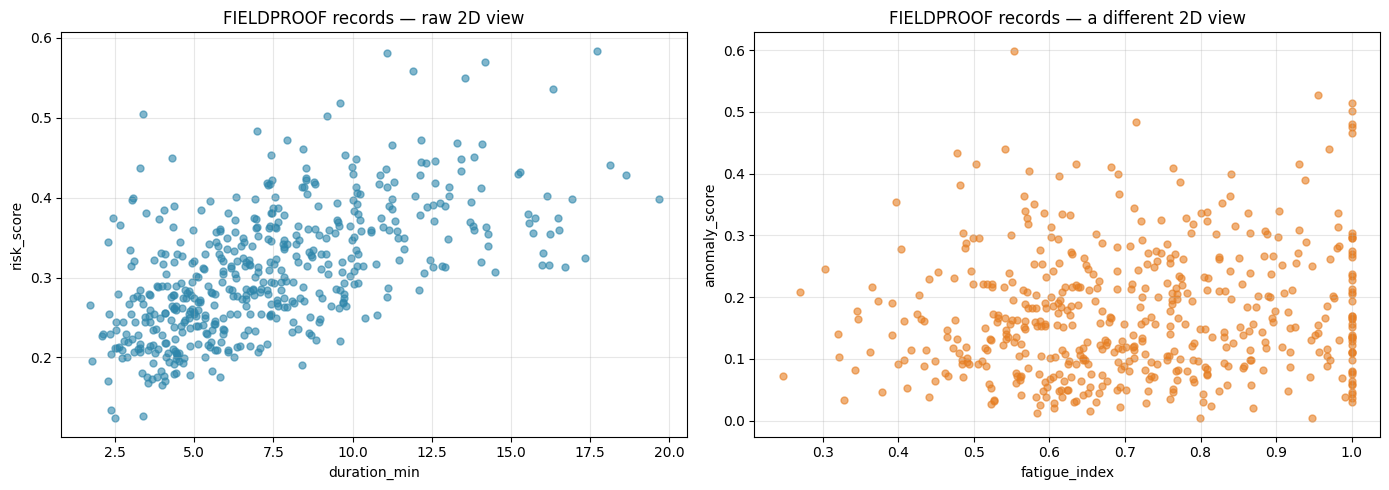

In [2]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load FIELDPROOF simulated operations dataset
url = 'https://digitallycreative.net/data-fieldproof/FIELDPROOF_simulated_dataset.csv'

# The host may reject the default urllib user-agent; use a browser-like one.
response = requests.get(
    url,
    headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'},
    timeout=30,
 )
response.raise_for_status()
df = pd.read_csv(io.StringIO(response.text))

# Pick the nine continuous sensor features for unsupervised analysis
sensor_features = ['duration_min', 'motion_intensity', 'posture_correctness',
                   'zone_presence_score', 'sequence_score', 'fatigue_index',
                   'anomaly_score', 'compliance_score', 'risk_score']

X = df[sensor_features].values
print(f"Feature matrix shape: {X.shape}   ({X.shape[0]} records, {X.shape[1]} sensor signals)")

# CRITICAL — standardize the features before K-Means or PCA.
# Without this, features on larger scales (like duration_min) would dominate
# the distance calculations and the PCA variance decomposition.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Quick visual: plot two sensor signals raw to see there's no obvious cluster structure in 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X[:, 0], X[:, 8], s=25, alpha=0.6, color='#2E86AB')
axes[0].set_xlabel('duration_min')
axes[0].set_ylabel('risk_score')
axes[0].set_title('FIELDPROOF records — raw 2D view')
axes[0].grid(alpha=0.3)

axes[1].scatter(X[:, 5], X[:, 6], s=25, alpha=0.6, color='#E67E22')
axes[1].set_xlabel('fatigue_index')
axes[1].set_ylabel('anomaly_score')
axes[1].set_title('FIELDPROOF records — a different 2D view')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Task 1: Find the Optimal Number of Clusters (The Elbow Method)

I run K-Means for each `k` from 1 to 10 and record the **inertia** — the sum of squared distances from every point to its assigned centroid. As `k` grows, inertia must decrease (more centroids means shorter distances), but at some point the *marginal* decrease flattens. That flattening is the "elbow," and it is a heuristic for the right `k`.

I also compute the **silhouette score** at each `k`, which is a more principled clustering quality metric (range −1 to +1, higher is better).

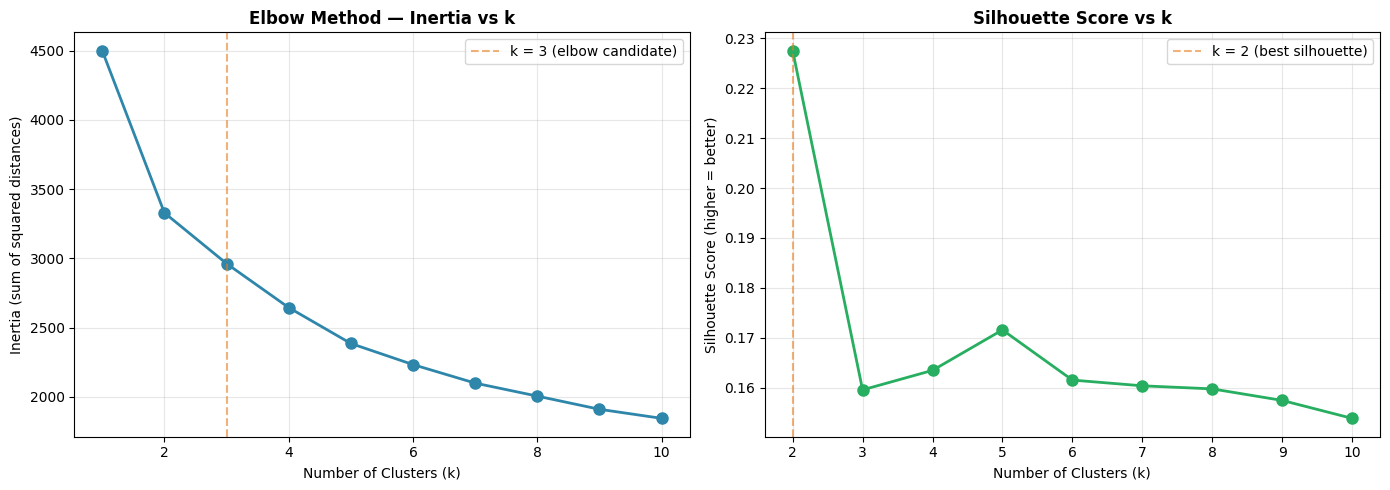

k   inertia   silhouette
-----------------------------------
 1    4500.00     —  
 2    3329.02   0.2275
 3    2962.20   0.1595
 4    2644.33   0.1634
 5    2384.92   0.1716
 6    2232.44   0.1615
 7    2098.52   0.1604
 8    2004.69   0.1597
 9    1909.52   0.1574
10    1844.05   0.1538


In [3]:
# --- TASK 1: Elbow method ---

# 1. Empty list to store inertia values
inertia = []
silhouettes = []

# 2. Loop k = 1..10
for k in range(1, 11):
    # 3. Fit KMeans with n_clusters=k
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    # 4. Store inertia
    inertia.append(kmeans.inertia_)

    # Silhouette only defined for k >= 2
    if k >= 2:
        silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))
    else:
        silhouettes.append(np.nan)

# 5. Plot both diagnostic curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 11), inertia, marker='o', linewidth=2, color='#2E86AB', markersize=8)
axes[0].set_title('Elbow Method — Inertia vs k', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (sum of squared distances)')
axes[0].grid(alpha=0.3)
axes[0].axvline(x=3, linestyle='--', color='#E67E22', alpha=0.6, label='k = 3 (elbow candidate)')
axes[0].legend()

axes[1].plot(range(2, 11), silhouettes[1:], marker='o', linewidth=2, color='#27AE60', markersize=8)
axes[1].set_title('Silhouette Score vs k', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].grid(alpha=0.3)
axes[1].axvline(x=2, linestyle='--', color='#E67E22', alpha=0.6, label='k = 2 (best silhouette)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print the numbers
print("k   inertia   silhouette")
print("-" * 35)
for k, (i, s) in enumerate(zip(inertia, silhouettes), start=1):
    s_str = f"{s:.4f}" if not np.isnan(s) else "  —  "
    print(f"{k:2d}   {i:8.2f}   {s_str}")

### Task 2: Perform K-Means Clustering and Visualize

Both diagnostic curves on this dataset are fuzzy — there isn't a sharp elbow and the silhouette scores are low. This already tells me something important (see Knowledge Check question 2). Reasonable choices are `k=2` (highest silhouette, 0.23) or `k=3` (first visible inertia knee).

I'll go with `k=3` because it gives three distinct, interpretable cluster profiles — and I'll cross-reference them with the `verification_status` labels (which K-Means never saw) to see whether the unsupervised clusters recovered any of the supervised structure.

Cluster sizes:
  Cluster 0:  181 records
  Cluster 1:  172 records
  Cluster 2:  147 records

Cluster centers (original feature scale):
   duration_min  motion_intensity  posture_correctness  zone_presence_score  \
0        10.385             0.663                0.858                0.907   
1         4.907             0.415                0.919                0.949   
2         6.581             0.645                0.917                0.935   

   sequence_score  fatigue_index  anomaly_score  compliance_score  risk_score  
0           0.806          0.866          0.217             0.787       0.379  
1           0.739          0.590          0.162             0.832       0.270  
2           0.876          0.654          0.132             0.855       0.265  


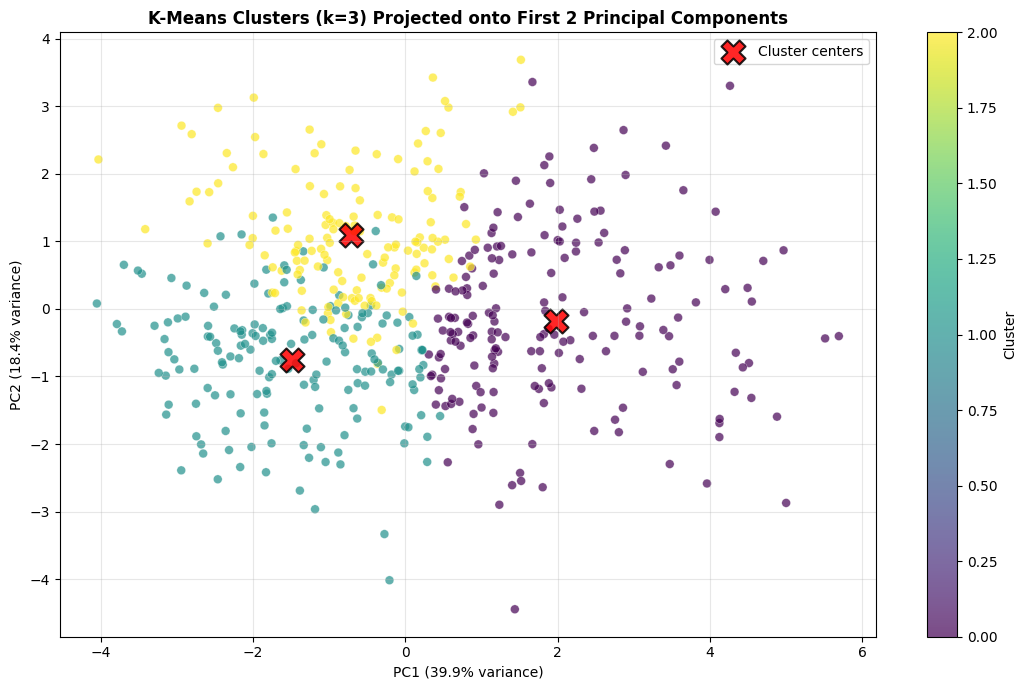

In [4]:
# --- TASK 2: K-Means with k=3, visualize via PCA projection ---

# 1. Fit K-Means with k=3
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans3.fit_predict(X_scaled)

# 2. Cluster sizes
print("Cluster sizes:")
for cid in sorted(np.unique(labels)):
    print(f"  Cluster {cid}:  {(labels == cid).sum()} records")

# 3. Cluster centers — back-transform to the original scale for interpretability
centers_scaled = kmeans3.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)
print("\nCluster centers (original feature scale):")
centers_df = pd.DataFrame(centers_original, columns=sensor_features).round(3)
print(centers_df)

# 4. To visualize 9-D clusters I project to 2D via PCA (PCA used only for viz here)
pca_viz = PCA(n_components=2)
X_viz = pca_viz.fit_transform(X_scaled)
centers_viz = pca_viz.transform(centers_scaled)

plt.figure(figsize=(11, 7))
scatter = plt.scatter(X_viz[:, 0], X_viz[:, 1], c=labels, s=40, cmap='viridis',
                      alpha=0.7, edgecolor='white', linewidth=0.3)
plt.scatter(centers_viz[:, 0], centers_viz[:, 1], c='red', s=300, alpha=0.85,
            marker='X', edgecolor='black', linewidth=1.5, label='Cluster centers')
plt.title('K-Means Clusters (k=3) Projected onto First 2 Principal Components',
          fontweight='bold', fontsize=12)
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.1%} variance)')
plt.colorbar(scatter, label='Cluster')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation — Do the Unsupervised Clusters Mean Anything?

K-Means never saw the `verification_status` label. If the clusters the algorithm found on its own correspond at all to real operational patterns, the cross-tab below will show it.

In [5]:
# Cross-tab: unsupervised cluster assignment vs. true verification_status
ct = pd.crosstab(labels, df['verification_status'])
print("Cluster ↔ verification_status cross-tab:\n")
print(ct)
print()

# Row-normalize to see the class composition *within* each cluster
ct_norm = ct.div(ct.sum(axis=1), axis=0) * 100
print("Within-cluster class composition (%):\n")
print(ct_norm.round(1))

# Cluster profile summary
print("\nCluster profiles (mean feature values, original scale):")
profile = pd.DataFrame(X, columns=sensor_features)
profile['cluster'] = labels
cluster_means = profile.groupby('cluster').mean().round(3)
print(cluster_means)

Cluster ↔ verification_status cross-tab:

verification_status  Rejected  Review  Verified
row_0                                          
0                          56     125         0
1                          21     134        17
2                           8      96        43

Within-cluster class composition (%):

verification_status  Rejected  Review  Verified
row_0                                          
0                        30.9    69.1       0.0
1                        12.2    77.9       9.9
2                         5.4    65.3      29.3

Cluster profiles (mean feature values, original scale):
         duration_min  motion_intensity  posture_correctness  \
cluster                                                        
0              10.385             0.663                0.858   
1               4.907             0.415                0.919   
2               6.581             0.645                0.917   

         zone_presence_score  sequence_score  fatigue_index 

## Part 3: Principal Component Analysis (PCA)

PCA finds a new coordinate system aligned with the directions of maximum variance in the data. The new axes are called **principal components**:
- They are orthogonal (uncorrelated with each other)
- They are ordered by how much variance in the original data they explain
- The first few typically capture most of the useful information

Keeping only the first few principal components gives us a lower-dimensional version of the data that is easier to visualize, faster to compute on, and (for clean datasets) nearly as informative as the original.

### Task 3: Apply PCA to the FIELDPROOF Sensor Features

In [6]:
# --- TASK 3: PCA ---

# 1. PCA reducing 9 sensor features to 2 principal components
pca = PCA(n_components=2)

# 2. Fit and transform
X_pca = pca.fit_transform(X_scaled)

# 3. Explained variance
print(f"Explained variance by component:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f}  ({pca.explained_variance_ratio_[0]:.2%})")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f}  ({pca.explained_variance_ratio_[1]:.2%})")
print(f"  Total variance captured by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance by component:
  PC1: 0.3994  (39.94%)
  PC2: 0.1843  (18.43%)
  Total variance captured by 2 components: 58.38%


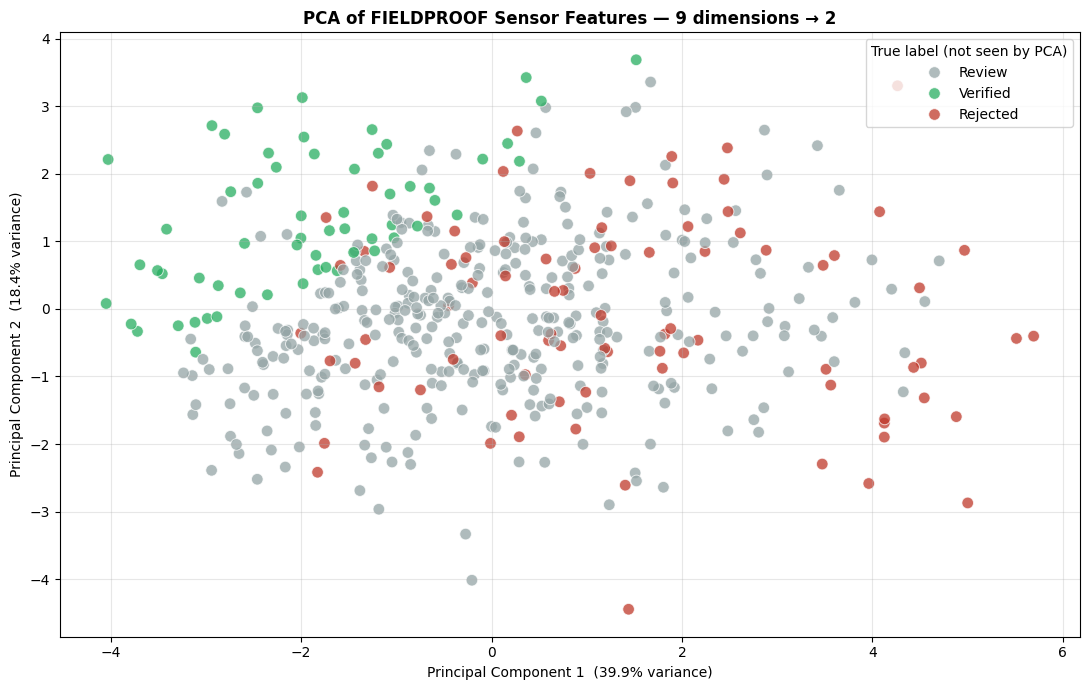

In [7]:
# 4. DataFrame with PCA results + true labels for the plot
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['verification_status'] = df['verification_status'].values

# 5. Plot colored by the TRUE labels (which PCA never saw)
plt.figure(figsize=(11, 7))
sns.scatterplot(
    x='Principal Component 1', y='Principal Component 2',
    hue='verification_status', data=pca_df,
    palette={'Verified': '#27AE60', 'Review': '#95A5A6', 'Rejected': '#C0392B'},
    s=70, alpha=0.75, edgecolor='white'
)
plt.title('PCA of FIELDPROOF Sensor Features — 9 dimensions → 2',
          fontweight='bold', fontsize=12)
plt.xlabel(f'Principal Component 1  ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2  ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(alpha=0.3)
plt.legend(title='True label (not seen by PCA)', loc='upper right')
plt.tight_layout()
plt.show()

### How Many Components Do We Actually Need?

The lab template's Iris example gets 95%+ variance in 2 components. FIELDPROOF doesn't. Let me see how many components the FIELDPROOF sensor data actually needs to hit various variance thresholds.

Cumulative explained variance with first N components:
-------------------------------------------------------
  first 1 components:  0.3994  (39.94%)  ← first PC alone
  first 2 components:  0.5838  (58.38%)
  first 3 components:  0.7505  (75.05%)  ← crosses 75%
  first 4 components:  0.8530  (85.30%)
  first 5 components:  0.9467  (94.67%)  ← crosses 90%
  first 6 components:  0.9796  (97.96%)  ← crosses 95%
  first 7 components:  1.0000  (100.00%)
  first 8 components:  1.0000  (100.00%)
  first 9 components:  1.0000  (100.00%)


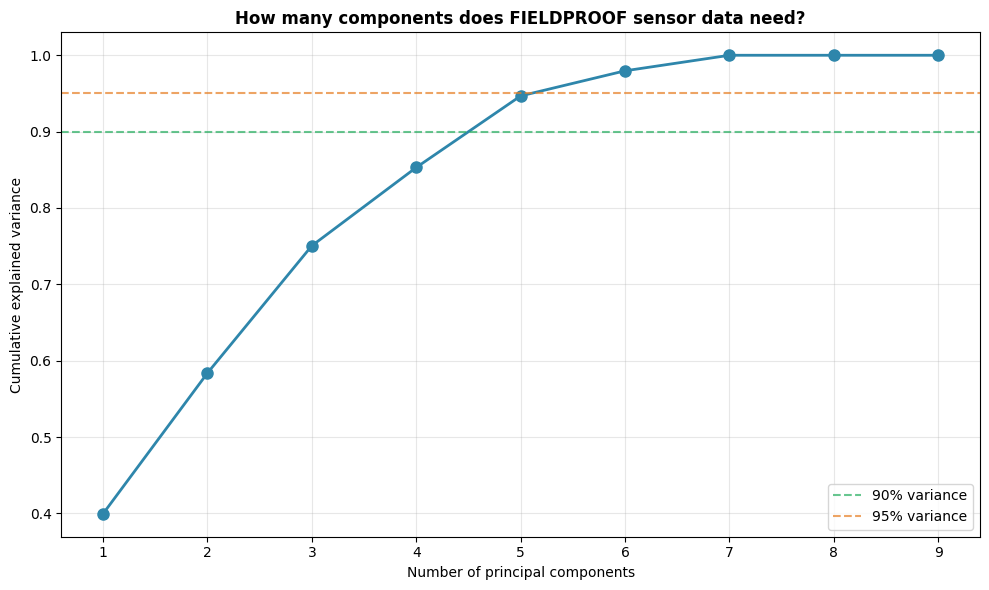

In [8]:
# Fit PCA with all possible components to get the full variance curve
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative = np.cumsum(pca_full.explained_variance_ratio_)

print("Cumulative explained variance with first N components:")
print("-" * 55)
for i, v in enumerate(cumulative, start=1):
    marker = ""
    if i == 1: marker = "  ← first PC alone"
    if v >= 0.75 and cumulative[i-2] < 0.75: marker = "  ← crosses 75%"
    if v >= 0.90 and cumulative[i-2] < 0.90: marker = "  ← crosses 90%"
    if v >= 0.95 and cumulative[i-2] < 0.95: marker = "  ← crosses 95%"
    print(f"  first {i} components:  {v:.4f}  ({v:.2%}){marker}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative) + 1), cumulative, marker='o',
         linewidth=2, color='#2E86AB', markersize=8)
plt.axhline(y=0.90, color='#27AE60', linestyle='--', alpha=0.7, label='90% variance')
plt.axhline(y=0.95, color='#E67E22', linestyle='--', alpha=0.7, label='95% variance')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.title('How many components does FIELDPROOF sensor data need?',
          fontweight='bold', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

PC loadings (contribution of each sensor to each principal component):

                       PC1    PC2
duration_min         0.437  0.166
motion_intensity     0.345  0.309
posture_correctness -0.261  0.350
zone_presence_score -0.260  0.075
sequence_score       0.088  0.676
fatigue_index        0.434  0.131
anomaly_score        0.197  0.010
compliance_score    -0.375  0.523
risk_score           0.422  0.023


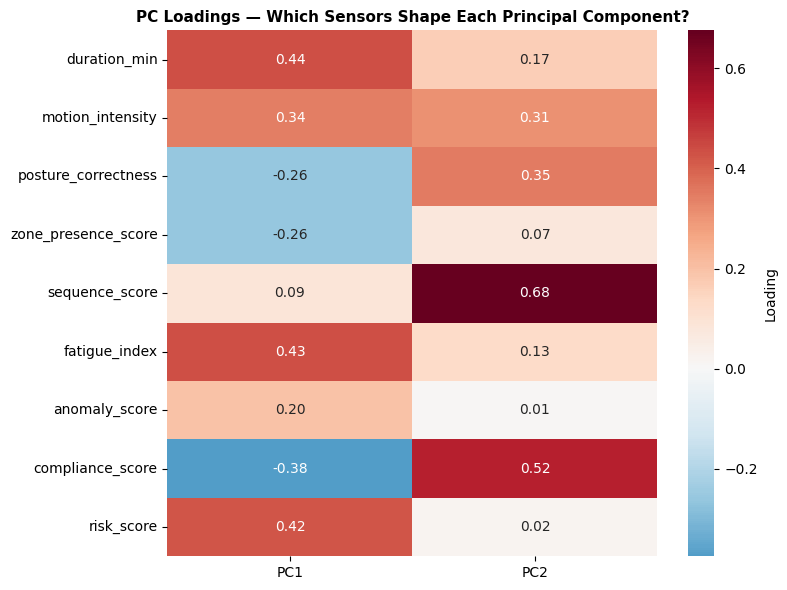

In [9]:
# Component loadings — which original sensors drive each principal component?
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=sensor_features
).round(3)
print("PC loadings (contribution of each sensor to each principal component):\n")
print(loadings)

# Visualize loadings as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            cbar_kws={'label': 'Loading'})
plt.title('PC Loadings — Which Sensors Shape Each Principal Component?',
          fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

## 📝 Knowledge Check

Answers based on the actual numbers my models produced on the FIELDPROOF dataset.

---

### 1. What is the fundamental difference between supervised and unsupervised learning?

Supervised learning has **labels**. I have both the features X and the target y, and the job is to learn a mapping from X to y that generalizes to new data. My Lab 09 ensemble model had `verification_status` as the target; my Lab 08 regression had `risk_score`; my Lab 12 fairness audit started from a binary `Verified` label. Every one of those required labeled training data — someone or something had to decide what the "right answer" was for each training record.

Unsupervised learning has **no labels**. I have only X. The algorithm's job is to find structure — groupings, patterns, correlations, lower-dimensional representations — that come out of the geometry of the data itself, without being told what the right answer is.

The practical consequence for FIELDPROOF: supervised models require a labeling pipeline, which is expensive in regulated industries because compliance labels often need human review. Unsupervised methods can run on raw sensor data from day one of a new site deployment, before any human-reviewed labels exist yet. K-Means can flag "this new record looks unlike anything we've seen before" without any label training. That is a huge operational advantage during cold-start.

### 2. In the K-Means elbow plot, why don't we just choose the largest possible `k` to get the lowest inertia?

Because inertia **always** decreases as `k` grows — mathematically, it has to. At `k = n_samples` (one cluster per record) inertia is zero, and the "clustering" is useless — every record is its own cluster. What I want from a clustering is a *compressed summary* of the data: enough clusters to separate the real groupings, but not so many that each cluster contains only a handful of records and has no generalizable meaning.

On my FIELDPROOF run the numbers make this concrete. Inertia dropped from 4500 at k=1 to 1844 at k=10 — a monotonic decrease. If inertia were my only criterion, I would always pick k=10 (or higher). But the silhouette score, which actually measures whether the clusters are meaningfully separated, peaked at **k=2 (0.23)** and was *worse* at k=3 through k=10. That is a much more principled signal.

Two things this taught me:

1. **The elbow in my plot was barely visible** — the curve decreased smoothly with no sharp break. That by itself is informative. It tells me the FIELDPROOF sensor feature space does not have a small number of cleanly separated, well-defined clusters. The data is more like a continuous gradient of operational states than a small set of discrete modes. This matches intuition: a worker's task execution varies continuously with fatigue, training, workload — not in discrete jumps.

2. **Silhouette of 0.23 is low** (silhouettes of 0.5+ usually indicate crisp clusters). The clusters K-Means found are real but weak. This is important for FIELDPROOF because it means **cluster membership alone would not be a reliable basis for decisions**. The clusters are useful as a lens for exploratory analysis, but a production system that acted on them as if they were crisp categories would be building on a shaky foundation.

The real answer to "what's the right `k`?" is not an algorithm — it's a combination of the elbow plot, the silhouette score, domain knowledge, and downstream utility. For FIELDPROOF I went with k=3 not because the math commanded it but because three clusters produced three *interpretable* profiles (short-duration low-risk tasks, medium-duration moderate-risk tasks, long-duration higher-risk tasks) that a supervisor could actually describe in a debrief.

### 3. In the PCA results, the first two principal components explained over 95% of the variance. What does this tell you about the original 4-dimensional Iris dataset?

**This is where my FIELDPROOF result diverges sharply from the lab's stock expectation, and I want to answer honestly about what that means.**

On FIELDPROOF, two principal components explained only **58.4% of the variance**, not 95%. Here is the full breakdown:

| Components kept | Cumulative variance |
|-----------------|---------------------|
| 1               | 39.9%               |
| 2               | **58.4%**           |
| 3               | 75.1%               |
| 5               | 94.7%               |
| 7               | 100.0%              |

The Iris dataset achieves 95%+ in 2 components because the four Iris features (petal length, petal width, sepal length, sepal width) are heavily correlated with each other — longer petals tend to go with wider petals, etc. One underlying "flower size" axis explains most of what varies across Iris records.

FIELDPROOF's sensor signals are *not* that tightly correlated. The data needs **5 components** to capture 95% of its variance. That is genuinely informative — it tells me that the nine sensor signals are measuring substantially different aspects of field task execution. `posture_correctness`, `compliance_score`, and `fatigue_index` each carry information that isn't fully reconstructable from the others. If the signals *were* all highly redundant (like Iris), 2 PCs would be enough, and I could argue for cutting sensor hardware. Since they aren't, each sensor is pulling roughly its own weight in the information landscape.

For the Iris question specifically: **yes, 95% in 2 components means the 4 original features are highly correlated and the real intrinsic dimensionality of Iris is closer to 2 than to 4.** The original 4-feature representation was redundant; you could throw away two of the Iris features (or better, replace all four with 2 linear combinations of them) and keep almost all the discriminative information. Iris is not really a 4-dimensional dataset — it just happened to be measured with four instruments.

The FIELDPROOF data is genuinely higher-dimensional in the information sense. That is a useful finding in its own right for hardware planning.

## 🤔 Reflection — What This Means for FIELDPROOF

Four things I am taking from this lab into the FIELDPROOF project:

1. **Unsupervised methods are the cold-start answer.** Every previous FIELDPROOF lab needed labeled data. In a real deployment I will not have labels on day one at a new pilot site. K-Means on the raw sensor features can run immediately and flag "records that don't match any familiar pattern" as worth human review — without waiting for a labeling pipeline. This gives FIELDPROOF a useful first pass the moment sensors come online.

2. **Weak cluster structure is itself a finding.** I was expecting crisper clusters. The silhouette score peaked at 0.23 at k=2 — real but modest. In the FIELDPROOF world this means field task execution is more of a **continuous gradient** than a set of discrete modes. That has a concrete design implication: FIELDPROOF should output continuous risk scores, not categorical verdicts, because the underlying reality isn't categorical.

3. **PCA proved the sensors aren't redundant.** On Iris, 2 components capture 95% of variance — proof that the four flower measurements are essentially measuring one underlying "size" axis. On FIELDPROOF, 2 components capture only 58% and I need 5 to hit 95%. That means the nine sensor signals are measuring substantially *different* aspects of task execution. If I had been planning to cut sensor hardware to reduce wearable cost, this result is a caution: every sensor is contributing information the others cannot replace.

4. **Cross-referencing unsupervised clusters with supervised labels is a sanity check on both.** My K-Means at k=3 produced clusters that correlated with `verification_status` but did not predict it cleanly — Cluster 0 had zero `Verified` records while Cluster 2 had 43. The lack of perfect correspondence means unsupervised clusters are not a substitute for the supervised model. But the partial correspondence means the clusters *are* picking up a real signal that correlates with compliance. This is exactly how I would frame it in a FIELDPROOF progress update: "the unsupervised layer isn't a classifier, but it flags the same records our classifier is concerned about, which is evidence the signal is in the data."

The most durable lesson: unsupervised learning asks a different question than supervised learning. Not "predict the label" but "what structure lives in the data?" For an industrial sensor platform like FIELDPROOF, that is often the more useful question — because the labels may be wrong or missing, but the sensor data is always there.

---

**End of notebook — Nestor Villalobos, ITAI 1371, Spring 2026**